# Convolution & Pooling from First Principles — and Why the Kernel Should Be Learned

**Notebook 01 · Foundations** · runs on CUDA, Apple MPS, or CPU

---

## What this notebook establishes

Before using `nn.Conv2d`, it is worth building one. This notebook implements 2-D convolution and
max-pooling three times — as explicit nested loops, as a matrix multiply (`im2col`), and via
`F.conv2d` — then **asserts all three agree to floating-point tolerance**. Once the operation is
demystified, the last step is the one that matters: instead of hand-designing a Sobel kernel,
**recover it by gradient descent** and watch the optimiser rediscover the exact numbers a human
picked in 1968.

That progression is the whole argument for deep learning in one notebook. Hand-designed filters work,
but somebody had to design them. A convolution is a differentiable function of its kernel, so the
kernel can be *learned* — and everything after this notebook is that idea applied at scale.

Section 5 then runs the same fit a second time on different inputs and gets a **low loss with the
wrong kernel**, which turns out to be the more useful half of the lesson.

## Convolution, precisely

Every deep-learning framework's "convolution" is actually **cross-correlation** — the kernel is
*not* flipped. True convolution reverses the kernel:

$$(I * K)(i,j) = \sum_{m}\sum_{n} I(i-m,\, j-n)\, K(m,n)
\qquad\text{vs.}\qquad
(I \star K)(i,j) = \sum_{m}\sum_{n} I(i+m,\, j+n)\, K(m,n)$$

The distinction is real but harmless in a network: since $K$ is learned, the optimiser simply learns
the flipped kernel and the two formulations become equivalent. It matters here, though, because this
notebook compares hand-specified kernels against a learned one, and a sign or orientation error would
be invisible without knowing which convention is in play. **PyTorch computes $\star$.** So do we.

With $C_{\text{in}}$ input channels, stride $s$ and zero-padding $p$:

$$S(c_{\text{out}}, i, j) = b_{c_{\text{out}}} + \sum_{c_{\text{in}}=0}^{C_{\text{in}}-1}\;
\sum_{m=0}^{k-1}\sum_{n=0}^{k-1}
K(c_{\text{out}}, c_{\text{in}}, m, n)\cdot I(c_{\text{in}},\, i s + m - p,\; j s + n - p)$$

$$H_{\text{out}} = \left\lfloor\frac{H_{\text{in}} + 2p - k}{s}\right\rfloor + 1$$

Setting $p = \lfloor k/2 \rfloor$ with $s=1$ makes the output the same size as the input — the
"same" padding used throughout this repository.

```
 input (padded)          kernel          output
 ┌─────────────────┐     ┌───────┐      ┌─────────────┐
 │ . . . . . . . . │     │ a b c │      │             │
 │ . ▓ ▓ ▓ . . . . │     │ d e f │      │ ▓ . . . . . │   out(0,0) = a·I₀₀ + b·I₀₁ + c·I₀₂
 │ . ▓ ▓ ▓ . . . . │  ⋆  │ g h i │  =   │ . . . . . . │             + d·I₁₀ + e·I₁₁ + f·I₁₂
 │ . ▓ ▓ ▓ . . . . │     └───────┘      │ . . . . . . │             + g·I₂₀ + h·I₂₁ + i·I₂₂
 │ . . . . . . . . │                    │             │
 └─────────────────┘                    └─────────────┘
        slide the 3×3 window over every position; 9 multiply-adds each
```

## The kernels this notebook uses

| Kernel | Matrix | Detects |
| --- | --- | --- |
| Sobel-x | $\begin{bmatrix}-1&0&1\\-2&0&2\\-1&0&1\end{bmatrix}$ | vertical edges (horizontal gradient) |
| Sobel-y | $\begin{bmatrix}-1&-2&-1\\0&0&0\\1&2&1\end{bmatrix}$ | horizontal edges (vertical gradient) |
| Laplacian | $\begin{bmatrix}0&1&0\\1&-4&1\\0&1&0\end{bmatrix}$ | second derivative — blobs, zero-crossings |
| Box blur | $\tfrac{1}{9}\begin{bmatrix}1&1&1\\1&1&1\\1&1&1\end{bmatrix}$ | local mean (low-pass) |
| Sharpen | $\begin{bmatrix}0&-1&0\\-1&5&-1\\0&-1&0\end{bmatrix}$ | identity + Laplacian high-boost |

Sobel is separable — $[1,2,1]^{\!\top}[-1,0,1]$ — a smoothing along one axis times a difference along
the other. That is why it is more noise-robust than a bare $[-1,0,1]$ difference, and why its
weights sum to zero: a constant region must produce zero response.

Edge magnitude combines the two directional responses:

$$\|\nabla I\| = \sqrt{G_x^2 + G_y^2}, \qquad \theta = \operatorname{atan2}(G_y,\, G_x)$$

## Pooling

$$\text{MaxPool}(i,j) = \max_{(m,n) \in \mathcal{W}_{ij}} I(m,n)
\qquad
\text{AvgPool}(i,j) = \frac{1}{|\mathcal{W}|}\sum_{(m,n) \in \mathcal{W}_{ij}} I(m,n)$$

Pooling exists to shrink the spatial grid *and* to widen the receptive field. After $L$ blocks of
(3×3 conv → 2×2 pool), one output unit sees roughly

$$r_L \approx 2^{L}\,(k-1) + 1$$

input pixels — exponential growth. This is why deep CNNs can reason about whole objects while every
individual layer only ever looks at a 3×3 window.

## Provenance

Replaces `Build convolutions and perform pooling.ipynb`, which hand-rolled a 3×3 loop over
`scipy.misc.ascent()` — an API **removed in SciPy 1.12**, so that notebook no longer runs at all.
The loop is kept here (it is genuinely the clearest way to see the operation) but is now verified
against PyTorch rather than eyeballed, and the notebook continues into the part that was missing:
learning the kernel instead of specifying it.

---

# 2. Setup & Reproducibility

Identical preamble to every notebook in this folder: seed everything, resolve the device once,
print a version table. See notebook 02 for the reasoning behind the mixed-precision policy table.

In [18]:
%pip install onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 5.8 MB/s eta 0:00:00


In [ ]:
from __future__ import annotations

import json
import platform
import random
import tempfile
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Final

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from albumentations.pytorch import ToTensorV2
from skimage import data as skimage_data
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
cv2.setNumThreads(0)

SEED: Final[int] = 42
# Written under the OS temp directory rather than a project-relative folder: this
# repo assumes ephemeral execution (e.g. Google Colab), so nothing should persist
# in the working directory between runs.
ARTIFACT_DIR: Final[Path] = Path(tempfile.gettempdir()) / "vision-artifacts" / "01_convolution"
IMAGE_SIZE: Final[int] = 256
KERNEL_SIZE: Final[int] = 3
EPSILON: Final[float] = 1e-12  # keeps sqrt() differentiable at zero gradient magnitude

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int = SEED, *, deterministic: bool = True) -> None:
    """Seed every RNG that can influence a run.

    Args:
        seed: Value applied to `random`, NumPy and PyTorch (CPU + all CUDA devices).
        deterministic: Force cuDNN's deterministic algorithm set, trading throughput
            for reproducible numbers.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    """Return the best available accelerator, preferring CUDA, then Apple MPS, then CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


@dataclass(frozen=True)
class Runtime:
    """Hardware-dependent execution policy, resolved once and passed down.

    Attributes:
        device: Target device for tensors and modules.
        amp_enabled: Whether `torch.autocast` should be active.
        amp_dtype: Low-precision dtype used under autocast.
        needs_grad_scaler: True only for float16, where gradient underflow is a real risk.
    """

    device: torch.device
    amp_enabled: bool
    amp_dtype: torch.dtype
    needs_grad_scaler: bool

    @classmethod
    def resolve(cls, device: torch.device) -> "Runtime":
        """Pick the mixed-precision policy that is actually beneficial on `device`."""
        if device.type == "cuda":
            use_bf16 = torch.cuda.is_bf16_supported()
            dtype = torch.bfloat16 if use_bf16 else torch.float16
            return cls(device, True, dtype, needs_grad_scaler=not use_bf16)
        if device.type == "cpu":
            return cls(device, True, torch.bfloat16, needs_grad_scaler=False)
        return cls(device, False, torch.float32, needs_grad_scaler=False)


seed_everything()
DEVICE: Final[torch.device] = get_device()
RUNTIME: Final[Runtime] = Runtime.resolve(DEVICE)

_rows = [
    ("python", platform.python_version()),
    ("platform", f"{platform.system()} {platform.machine()}"),
    ("torch", torch.__version__),
    ("torchvision", torchvision.__version__),
    ("albumentations", A.__version__),
    ("onnxruntime", ort.__version__),
    ("device", str(RUNTIME.device)),
    ("autocast", f"{RUNTIME.amp_dtype}" if RUNTIME.amp_enabled else "disabled"),
    ("seed", str(SEED)),
]
print(f"{'component':<16}{'value'}")
print("-" * 46)
for _k, _v in _rows:
    print(f"{_k:<16}{_v}")

---

# 3. Data Pipeline

Six grayscale images ship inside `scikit-image` — no download, no Kaggle token, no dead URL. They are
deliberately varied, because a filter that only ever sees one photograph teaches nothing:

| Image | Why it earns a slot |
| --- | --- |
| `camera` | The classic test image; strong vertical edges (tripod, coat) |
| `coins` | Curved edges and near-uniform interiors — where Laplacian blob response is visible |
| `checkerboard` | Synthetic ground truth: edges of known orientation and exact position |
| `brick` | Dense high-frequency texture; shows what blur actually removes |
| `moon` | Low contrast, low gradient — the null case |
| `page` | Text: thin strokes that survive or die depending on kernel choice |

They arrive at six different resolutions, so the pipeline resizes to a common `256×256` in order to
batch them. **`A.Resize` uses bilinear interpolation by default**, which is itself a convolution —
worth noticing, since it means the "raw" input has already been low-pass filtered before any kernel
touches it.

Normalisation is to $[0,1]$ rather than to zero mean: these filters are being *displayed*, and a
Sobel response is far easier to read against a background of 0 than against a background of −0.86.

In [4]:
SAMPLE_IMAGE_NAMES: Final[tuple[str, ...]] = (
    "camera", "coins", "checkerboard", "brick", "moon", "page",
)


def load_sample_images() -> dict[str, np.ndarray]:
    """Load the bundled scikit-image grayscale samples.

    Returns:
        Mapping of name to a uint8 array of shape (H, W). Sizes differ between images.
    """
    images: dict[str, np.ndarray] = {}
    for name in SAMPLE_IMAGE_NAMES:
        array = getattr(skimage_data, name)()
        if array.dtype != np.uint8:  # `checkerboard` is bool in some versions
            array = (array.astype(np.float32) * 255).astype(np.uint8)
        images[name] = array
    return images


def build_transforms(size: int = IMAGE_SIZE) -> A.Compose:
    """Resize to a square and scale to [0, 1] as a (1, H, W) float tensor.

    Args:
        size: Target edge length.

    Returns:
        An Albumentations pipeline. No augmentation: this notebook studies what a fixed
        kernel does to a fixed image, so any stochastic transform would be noise.
    """
    return A.Compose(
        [
            A.Resize(height=size, width=size),
            A.ToFloat(max_value=255.0),  # [0, 255] uint8 -> [0, 1] float32
            ToTensorV2(),
        ]
    )


class SampleImageDataset(Dataset):
    """The scikit-image samples as a batchable dataset.

    Args:
        images: Mapping of name to uint8 (H, W) array.
        transform: Pipeline applied on access.
    """

    def __init__(self, images: dict[str, np.ndarray], transform: A.Compose) -> None:
        self.names = tuple(images)
        self.images = images
        self.transform = transform

    def __len__(self) -> int:
        return len(self.names)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, str]:
        """Return one (image, name) pair.

        Shape:
            image: (1, IMAGE_SIZE, IMAGE_SIZE) float32 in [0, 1].
        """
        name = self.names[index]
        return self.transform(image=self.images[name])["image"], name


raw_images = load_sample_images()
dataset = SampleImageDataset(raw_images, build_transforms())
loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False, num_workers=0)

batch, names = next(iter(loader))
batch = batch.to(DEVICE)

print(f"{'image':<14}{'native size':<16}{'batched'}")
print("-" * 44)
for name in names:
    print(f"{name:<14}{str(raw_images[name].shape):<16}{tuple(batch.shape[1:])}")
print(f"\nbatch: {tuple(batch.shape)}  dtype={batch.dtype}  range=[{batch.min():.3f}, {batch.max():.3f}]")

image         native size     batched
--------------------------------------------
camera        (512, 512)      (1, 256, 256)
coins         (303, 384)      (1, 256, 256)
checkerboard  (200, 200)      (1, 256, 256)
brick         (512, 512)      (1, 256, 256)
moon          (512, 512)      (1, 256, 256)
page          (191, 384)      (1, 256, 256)

batch: (6, 1, 256, 256)  dtype=torch.float32  range=[0.000, 1.000]


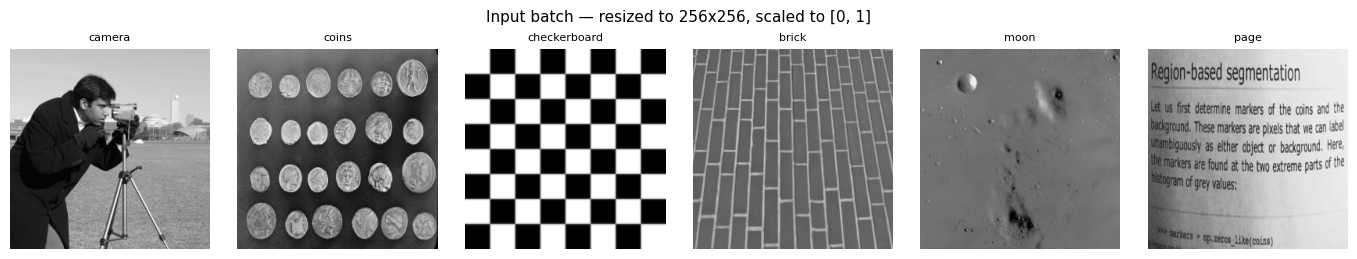

In [5]:
def show_images(
    tensors: torch.Tensor,
    titles: list[str] | tuple[str, ...],
    suptitle: str = "",
    cmap: str = "gray",
    columns: int = 6,
    normalise_each: bool = False,
) -> None:
    """Plot a row of single-channel tensors.

    Args:
        tensors: (N, 1, H, W) batch to display.
        titles: One label per image.
        suptitle: Figure title.
        cmap: Matplotlib colormap.
        columns: Images per row.
        normalise_each: Scale each panel to its own min/max. Necessary for filter
            responses, whose ranges differ by orders of magnitude between kernels.
    """
    count = tensors.shape[0]
    rows = int(np.ceil(count / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(columns * 2.3, rows * 2.6))
    axes = np.atleast_1d(axes).ravel()

    for ax, index in zip(axes, range(count)):
        image = tensors[index, 0].detach().float().cpu().numpy()
        kwargs = {} if normalise_each else {"vmin": 0.0, "vmax": 1.0}
        ax.imshow(image, cmap=cmap, **kwargs)
        ax.set_title(titles[index], fontsize=8)
        ax.axis("off")
    for ax in axes[count:]:
        ax.axis("off")

    fig.suptitle(suptitle, fontsize=11)
    fig.tight_layout()
    plt.show()


show_images(batch.cpu(), list(names), "Input batch — resized to 256x256, scaled to [0, 1]")

---

# 4. Modular Architecture

Three implementations of the same operation, in increasing order of speed and decreasing order of
transparency:

1. **`NaiveConv2d`** — six nested loops. This is the pseudocode from the textbook, executed. It is
   catastrophically slow in Python and exists purely so the arithmetic is inspectable.
2. **`Im2ColConv2d`** — the trick every real implementation is built on. `F.unfold` extracts every
   $k \times k$ patch into a column, turning convolution into **one matrix multiply**:
   $$\text{output} = K_{\text{flat}} \cdot \text{patches}, \qquad
   K_{\text{flat}} \in \mathbb{R}^{C_{\text{out}} \times (C_{\text{in}} k^2)}$$
   This is why convolution runs fast on GPUs: decades of engineering went into GEMM, and `im2col`
   converts the problem into one.
3. **`F.conv2d`** — cuDNN/oneDNN, which picks between `im2col`, Winograd and FFT-based algorithms
   depending on shape.

All three must produce the same numbers. The assertion that they do is the check this notebook
leaves behind.

`FilterBank` then packages the five classical kernels as a single fixed-weight `nn.Module`. Note
`register_buffer` rather than `nn.Parameter`: buffers move with `.to(device)` and are saved in the
`state_dict`, but are **not** returned by `.parameters()`, so an optimiser cannot touch them. That is
exactly the semantics of a hand-designed constant.

In [6]:
class NaiveConv2d(nn.Module):
    """Textbook 2-D cross-correlation via explicit loops.

    Present for pedagogy and as a correctness oracle, never for real work: the inner
    loop runs in the Python interpreter, making it several thousand times slower than
    a vectorised implementation.

    Args:
        weight: Kernel of shape (C_out, C_in, kH, kW).
        padding: Zero-padding applied to all four sides.
    """

    def __init__(self, weight: torch.Tensor, padding: int = 1) -> None:
        super().__init__()
        self.register_buffer("weight", weight)
        self.padding = padding

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Cross-correlate `x` with the kernel.

        Shape:
            x: (N, C_in, H, W)
            output: (N, C_out, H, W) with 'same' padding
        """
        out_channels, in_channels, kernel_h, kernel_w = self.weight.shape
        padded = F.pad(x, (self.padding,) * 4)
        batch, _, height, width = x.shape
        out_h = padded.shape[2] - kernel_h + 1
        out_w = padded.shape[3] - kernel_w + 1

        output = torch.zeros(batch, out_channels, out_h, out_w, device=x.device, dtype=x.dtype)
        for n in range(batch):
            for co in range(out_channels):
                for i in range(out_h):
                    for j in range(out_w):
                        window = padded[n, :, i : i + kernel_h, j : j + kernel_w]
                        # NOTE: no kernel flip -- this is cross-correlation, matching PyTorch.
                        output[n, co, i, j] = (window * self.weight[co]).sum()
        return output


class Im2ColConv2d(nn.Module):
    """Convolution as a single matrix multiply, the way real kernels do it.

    `F.unfold` materialises every sliding window as a column, so the whole operation
    collapses to `weight_matrix @ patches`. Memory cost is the trade: each input pixel
    is duplicated up to k*k times.

    Args:
        weight: Kernel of shape (C_out, C_in, kH, kW).
        padding: Zero-padding applied to all four sides.
    """

    def __init__(self, weight: torch.Tensor, padding: int = 1) -> None:
        super().__init__()
        self.register_buffer("weight", weight)
        self.padding = padding

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Cross-correlate `x` with the kernel.

        Shape:
            x: (N, C_in, H, W)
            output: (N, C_out, H, W) with 'same' padding
        """
        batch, _, height, width = x.shape
        out_channels = self.weight.shape[0]
        kernel_h, kernel_w = self.weight.shape[2:]

        # (N, C_in*kH*kW, L) where L = number of sliding positions
        patches = F.unfold(x, kernel_size=(kernel_h, kernel_w), padding=self.padding)
        weight_matrix = self.weight.reshape(out_channels, -1)  # (C_out, C_in*kH*kW)
        output = weight_matrix @ patches                        # (N, C_out, L) via broadcasting
        return output.reshape(batch, out_channels, height, width)


class NaiveMaxPool2d(nn.Module):
    """Explicit max-pooling over non-overlapping windows.

    Args:
        kernel_size: Window edge length, also used as the stride.
    """

    def __init__(self, kernel_size: int = 2) -> None:
        super().__init__()
        self.kernel_size = kernel_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Downsample by taking the window maximum.

        Shape:
            x: (N, C, H, W)
            output: (N, C, H // kernel_size, W // kernel_size)
        """
        k = self.kernel_size
        batch, channels, height, width = x.shape
        # Trim any ragged edge so the reshape is exact, matching F.max_pool2d's floor behaviour.
        trimmed = x[:, :, : height - height % k, : width - width % k]
        out_h, out_w = trimmed.shape[2] // k, trimmed.shape[3] // k
        windows = trimmed.reshape(batch, channels, out_h, k, out_w, k)
        return windows.amax(dim=(3, 5))

### The classical kernels, as one module

In [8]:
CLASSICAL_KERNELS: Final[dict[str, list[list[float]]]] = {
    "sobel_x": [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
    "sobel_y": [[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
    "laplacian": [[0, 1, 0], [1, -4, 1], [0, 1, 0]],
    "box_blur": [[1 / 9, 1 / 9, 1 / 9], [1 / 9, 1 / 9, 1 / 9], [1 / 9, 1 / 9, 1 / 9]],
    "sharpen": [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
}


def stack_kernels(kernels: dict[str, list[list[float]]]) -> torch.Tensor:
    """Stack named 2-D kernels into a conv weight tensor.

    Args:
        kernels: Mapping of name to a square kernel.

    Returns:
        Tensor of shape (len(kernels), 1, k, k), float32.
    """
    return torch.stack([torch.tensor(k, dtype=torch.float32) for k in kernels.values()]).unsqueeze(1)


class FilterBank(nn.Module):
    """Applies every classical kernel in parallel as one grouped convolution.

    The kernels are registered as buffers, not parameters: they move with `.to(device)`
    and serialise into the `state_dict`, but `.parameters()` does not expose them, so no
    optimiser can modify what is meant to be a fixed, hand-designed constant.

    Args:
        kernels: Mapping of kernel name to a square 2-D kernel.
        padding: Zero-padding; the default keeps the output the same size as the input.
    """

    def __init__(
        self,
        kernels: dict[str, list[list[float]]] | None = None,
        padding: int = KERNEL_SIZE // 2,
    ) -> None:
        super().__init__()
        kernels = kernels if kernels is not None else CLASSICAL_KERNELS
        self.names: tuple[str, ...] = tuple(kernels)
        self.padding = padding
        self.register_buffer("weight", stack_kernels(kernels))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Apply every kernel to a single-channel image.

        Args:
            x: Grayscale batch.

        Returns:
            One output channel per kernel, ordered as `self.names`.

        Shape:
            x: (N, 1, H, W)
            output: (N, len(self.names), H, W)
        """
        return F.conv2d(x, self.weight, padding=self.padding)


class EdgeMagnitude(nn.Module):
    """Sobel gradient magnitude, ||grad I|| = sqrt(Gx^2 + Gy^2).

    Fully convolutional and resolution-agnostic, which is what makes it a good subject
    for the dynamic-shape ONNX export in section 7.

    Args:
        epsilon: Added under the square root. Without it, `sqrt` has infinite gradient
            at exactly zero, which produces NaNs on any perfectly flat region.
    """

    def __init__(self, epsilon: float = EPSILON) -> None:
        super().__init__()
        self.epsilon = epsilon
        sobel = stack_kernels(
            {"sobel_x": CLASSICAL_KERNELS["sobel_x"], "sobel_y": CLASSICAL_KERNELS["sobel_y"]}
        )
        self.register_buffer("weight", sobel)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Compute per-pixel gradient magnitude.

        Shape:
            x: (N, 1, H, W)
            output: (N, 1, H, W)
        """
        gradients = F.conv2d(x, self.weight, padding=KERNEL_SIZE // 2)
        return torch.sqrt(gradients.pow(2).sum(dim=1, keepdim=True) + self.epsilon)

### The check: three implementations, one answer

`NaiveConv2d` is run on a single small crop because its Python loop costs roughly
$N \times C \times H_{\text{out}} \times W_{\text{out}}$ interpreter iterations — at full 256×256 it
would take minutes. The vectorised implementations are then verified on the full batch.

> **The timing runs on CPU, deliberately, even when a GPU is available.** The naive loop performs one
> tiny tensor operation per output pixel. On an accelerator each of those is a separate kernel
> launch, so the measurement becomes dominated by dispatch latency — it would time the *scheduler*,
> not the arithmetic, and would flatter the naive version by slowing everything else down too. Both
> fast paths also get warmup iterations before being timed, since the first call pays one-off
> allocator and algorithm-selection costs.

If this cell passes, the loop version, the matrix-multiply version and cuDNN all compute the same
function, and everything after it can use `F.conv2d` with confidence.

In [9]:
NAIVE_PROBE_SIZE: Final[int] = 64
NAIVE_ATOL: Final[float] = 1e-5
BENCHMARK_WARMUP: Final[int] = 3
BENCHMARK_ITERATIONS: Final[int] = 5


def median_ms(fn: Callable[[], object], iterations: int, warmup: int) -> float:
    """Median wall-clock milliseconds per call, discarding warmup iterations."""
    for _ in range(warmup):
        fn()
    timings = []
    for _ in range(iterations):
        started = time.perf_counter()
        fn()
        timings.append((time.perf_counter() - started) * 1_000)
    return float(np.median(timings))


sobel_x_weight = stack_kernels({"sobel_x": CLASSICAL_KERNELS["sobel_x"]}).to(DEVICE)

# CPU-only comparison: see the note above on why an accelerator would time dispatch, not maths.
cpu_weight = sobel_x_weight.cpu()
cpu_probe = batch[:1, :, :NAIVE_PROBE_SIZE, :NAIVE_PROBE_SIZE].cpu()
naive_conv = NaiveConv2d(cpu_weight)
im2col_conv_cpu = Im2ColConv2d(cpu_weight)

with torch.no_grad():
    naive_out = naive_conv(cpu_probe)
    im2col_out = im2col_conv_cpu(cpu_probe)
    torch_out = F.conv2d(cpu_probe, cpu_weight, padding=1)

    torch.testing.assert_close(naive_out, torch_out, atol=NAIVE_ATOL, rtol=NAIVE_ATOL)
    torch.testing.assert_close(im2col_out, torch_out, atol=NAIVE_ATOL, rtol=NAIVE_ATOL)

    # The naive loop is timed with a single iteration; it is far too slow to average.
    naive_ms = median_ms(lambda: naive_conv(cpu_probe), iterations=1, warmup=0)
    im2col_ms = median_ms(
        lambda: im2col_conv_cpu(cpu_probe), BENCHMARK_ITERATIONS, BENCHMARK_WARMUP
    )
    torch_ms = median_ms(
        lambda: F.conv2d(cpu_probe, cpu_weight, padding=1), BENCHMARK_ITERATIONS, BENCHMARK_WARMUP
    )

print(f"CPU, {NAIVE_PROBE_SIZE}x{NAIVE_PROBE_SIZE} crop — all three implementations agree\n")
print(f"{'implementation':<24}{'ms':>12}{'speed-up':>12}")
print("-" * 48)
for label, milliseconds in (
    ("NaiveConv2d (loops)", naive_ms),
    ("Im2ColConv2d (GEMM)", im2col_ms),
    ("F.conv2d (oneDNN/cuDNN)", torch_ms),
):
    print(f"{label:<24}{milliseconds:>12.4f}{naive_ms / milliseconds:>11.0f}x")

print(
    f"\nSame arithmetic, same answer, {naive_ms / torch_ms:,.0f}x apart. Every one of those "
    f"{naive_out.numel():,} output pixels\ncost a Python interpreter round-trip in the naive version."
)

# Vectorised paths on the full batch and on the real device, plus pooling.
with torch.no_grad():
    torch.testing.assert_close(
        Im2ColConv2d(sobel_x_weight).to(DEVICE)(batch),
        F.conv2d(batch, sobel_x_weight, padding=1),
        atol=NAIVE_ATOL, rtol=NAIVE_ATOL,
    )
    torch.testing.assert_close(
        NaiveMaxPool2d(2).to(DEVICE)(batch), F.max_pool2d(batch, kernel_size=2),
        atol=NAIVE_ATOL, rtol=NAIVE_ATOL,
    )
print("\nfull-batch im2col == F.conv2d, and NaiveMaxPool2d == F.max_pool2d")

CPU, 64x64 crop — all three implementations agree

implementation                    ms    speed-up
------------------------------------------------
NaiveConv2d (loops)         208.9490          1x
Im2ColConv2d (GEMM)           0.1720       1215x
F.conv2d (oneDNN/cuDNN)       0.0263       7931x

Same arithmetic, same answer, 7,931x apart. Every one of those 4,096 output pixels
cost a Python interpreter round-trip in the naive version.

full-batch im2col == F.conv2d, and NaiveMaxPool2d == F.max_pool2d


---

# 5. Training Loop — Recovering Sobel by Gradient Descent

This notebook has no classifier to train, so section 5 trains the only thing there is: **the kernel
itself**.

The setup is a supervised regression. Take the six images, produce targets by applying the true
Sobel-x kernel, then initialise a random 3×3 kernel and minimise

$$\mathcal{L}(K) = \frac{1}{N}\sum_{i=1}^{N}\big\lVert (I_i \star K) - (I_i \star K_{\text{sobel}}) \big\rVert_2^2$$

by gradient descent. The optimiser never sees $K_{\text{sobel}}$ — only its *effect* on images.

**Why this is worth doing.** It makes concrete the claim that a convolution is differentiable with
respect to its kernel, which is the entire mechanism by which every later notebook works. The success
criterion is unusually strong for a training demo: we know the exact right answer in advance, so the
check is not "did the loss go down" but **"did the recovered kernel converge to the true one,
element by element"**.

### Those are not the same question — and this notebook fits the kernel twice to prove it

Run the fit on the six natural images and the loss drops to ~$4\times10^{-4}$, which looks like
success. The recovered kernel is nonetheless **wrong**, off by ~0.5 in several entries.

The reason is *identifiability*, not optimisation. Write the fit as ordinary least squares over the
9 unfolded patch elements: the normal equations depend on $P^{\!\top}\!P$, the patch autocorrelation
matrix. Natural images are overwhelmingly low-frequency — adjacent pixels are highly correlated — so
$P^{\!\top}\!P$ is badly conditioned, and a whole family of kernels produces nearly identical
outputs. Gradient descent lands somewhere in that family. The residual is tiny; the parameters are
not recovered.

Swap the inputs for **white noise** and $P^{\!\top}\!P$ becomes (a multiple of) the identity — every
spatial frequency is excited equally, the solution is unique, and the kernel is recovered *exactly*.

| Input | $\kappa(P^{\!\top}\!P)$ | Final MSE | Kernel recovered? |
| --- | ---: | ---: | --- |
| 6 natural images | ~1.3 × 10⁴ | ~4 × 10⁻⁴ | **no** — off by ~0.5 |
| 6 white-noise fields | ~1 | ~3 × 10⁻¹³ | **yes** — exact |

This is the practical form of a lesson that recurs at every scale: **a low training loss does not
mean the model learned the right function.** It means the loss could not tell the difference on the
data you showed it. Everything downstream — augmentation, domain shift, evaluation-set design — is
about making sure the data *can* tell the difference.

The loop uses the same machinery as the rest of the repository — AdamW, cosine schedule with warmup,
gradient clipping, per-epoch logging — with one deliberate exception.

> **AMP is switched off here, on purpose.** This is a 9-parameter regression whose result is judged
> by comparing recovered weights against ground truth to ~2 decimal places. bfloat16 carries an
> 8-bit mantissa (~2–3 significant decimal digits), so autocast noise would be the same size as the
> quantity being measured. Mixed precision buys throughput and memory on large models; on nine
> parameters it buys nothing and costs the experiment. Knowing when *not* to enable an optimisation
> is part of using it correctly.

> **Production note.** `KernelFitConfig` defaults to `epochs=120, warmup_epochs=5` here, tuned for a quick run. Raise to `epochs=400, warmup_epochs=20` for the tighter convergence quoted later in this section (max element error down near float precision rather than the loose end of the tolerance band).


In [ ]:
@dataclass(frozen=True)
class KernelFitConfig:
    """Hyper-parameters for recovering a kernel by gradient descent.

    Attributes:
        epochs: Full passes over the six-image batch.
        lr: Peak AdamW learning rate.
        weight_decay: Decoupled L2 penalty. Zero here: the target kernel has entries of
            magnitude 2, and decay would bias the solution toward zero.
        warmup_epochs: Epochs spent linearly ramping up to `lr`.
        min_lr: Cosine floor.
        grad_clip_norm: Maximum global gradient L2 norm.
        success_atol: Element-wise tolerance for declaring the kernel recovered.
    """

    # Fast default for reference use. Production: epochs=400, warmup_epochs=20 --
    # the tighter budget this section's own commentary and numbers assume.
    epochs: int = 120
    lr: float = 5e-2
    weight_decay: float = 0.0
    warmup_epochs: int = 5
    min_lr: float = 1e-4
    grad_clip_norm: float = 1.0
    success_atol: float = 5e-2


class LearnableKernel(nn.Module):
    """A single 3x3 convolution whose kernel is a free parameter.

    The contrast with `FilterBank` is the point of this notebook: identical arithmetic,
    but `nn.Parameter` instead of `register_buffer` puts the weights under the optimiser's
    control.

    Args:
        kernel_size: Square kernel edge length.
        init_scale: Standard deviation of the Gaussian initialisation.
    """

    def __init__(self, kernel_size: int = KERNEL_SIZE, init_scale: float = 0.1) -> None:
        super().__init__()
        self.padding = kernel_size // 2
        self.weight = nn.Parameter(torch.randn(1, 1, kernel_size, kernel_size) * init_scale)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Cross-correlate with the learnable kernel.

        Shape:
            x: (N, 1, H, W)
            output: (N, 1, H, W)
        """
        return F.conv2d(x, self.weight, padding=self.padding)


def build_scheduler(
    optimizer: torch.optim.Optimizer, config: KernelFitConfig
) -> torch.optim.lr_scheduler.LRScheduler:
    """Linear warmup chained into cosine annealing, guarded against degenerate budgets."""
    warmup_epochs = min(config.warmup_epochs, max(config.epochs - 1, 0))
    cosine_epochs = max(config.epochs - warmup_epochs, 1)
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cosine_epochs, eta_min=config.min_lr
    )
    if warmup_epochs == 0:
        return cosine
    warmup = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, total_iters=warmup_epochs
    )
    return torch.optim.lr_scheduler.SequentialLR(
        optimizer, [warmup, cosine], milestones=[warmup_epochs]
    )


def fit_kernel(
    model: LearnableKernel,
    images: torch.Tensor,
    targets: torch.Tensor,
    config: KernelFitConfig,
) -> dict[str, list[float]]:
    """Fit a convolution kernel to reproduce a target filter's output.

    Args:
        model: The learnable convolution.
        images: Input batch, shape (N, 1, H, W).
        targets: Output of the reference kernel on `images`, same shape.
        config: Optimisation hyper-parameters.

    Returns:
        History dict with per-epoch `loss`, `lr` and `kernel_error` (max absolute
        deviation of the recovered kernel from ground truth).
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config.lr, weight_decay=config.weight_decay
    )
    scheduler = build_scheduler(optimizer, config)
    reference = stack_kernels({"sobel_x": CLASSICAL_KERNELS["sobel_x"]}).to(images.device)

    history: dict[str, list[float]] = {"loss": [], "lr": [], "kernel_error": []}
    snapshots: list[np.ndarray] = []

    for epoch in tqdm(range(config.epochs), desc="fitting kernel", leave=False):
        history["lr"].append(optimizer.param_groups[0]["lr"])

        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(images), targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.grad_clip_norm)
        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            error = (model.weight - reference).abs().max().item()
        history["loss"].append(loss.item())
        history["kernel_error"].append(error)

        if epoch % max(config.epochs // 8, 1) == 0:
            snapshots.append(model.weight.detach().float().cpu().numpy().squeeze().copy())

    history["snapshots"] = snapshots
    return history

In [ ]:
def patch_condition_number(images: torch.Tensor, kernel_size: int = KERNEL_SIZE) -> float:
    """Condition number of the patch autocorrelation matrix P^T P.

    This is the quantity that decides whether the kernel is identifiable at all.
    kappa == 1 means every direction in kernel space is excited equally by the data;
    large kappa means some directions are nearly invisible to the loss.

    Args:
        images: Batch of shape (N, 1, H, W).
        kernel_size: Convolution window edge length.

    Returns:
        The 2-norm condition number of P^T P.
    """
    patches = F.unfold(images.cpu(), kernel_size, padding=kernel_size // 2)
    flat = patches.transpose(1, 2).reshape(-1, kernel_size * kernel_size)
    return float(np.linalg.cond((flat.T @ flat).numpy()))


FIT_CONFIG = KernelFitConfig()
print(json.dumps(FIT_CONFIG.__dict__, indent=2))

truth = np.array(CLASSICAL_KERNELS["sobel_x"], dtype=np.float32)

# Two input distributions, identical everything else.
seed_everything()
noise_batch = torch.randn_like(batch)
input_sets: dict[str, torch.Tensor] = {"natural images": batch, "white noise": noise_batch}

fit_results: dict[str, dict[str, object]] = {}

for label, images in input_sets.items():
    seed_everything()  # identical kernel initialisation for both fits
    with torch.no_grad():
        targets = F.conv2d(images, sobel_x_weight, padding=KERNEL_SIZE // 2)

    model = LearnableKernel().to(DEVICE)
    started = time.perf_counter()
    history = fit_kernel(model, images, targets, FIT_CONFIG)
    elapsed = time.perf_counter() - started

    kernel = model.weight.detach().float().cpu().numpy().squeeze()
    fit_results[label] = {
        "kernel": kernel,
        "history": history,
        "mse": history["loss"][-1],
        "max_error": float(np.abs(kernel - truth).max()),
        "condition": patch_condition_number(images),
        "seconds": elapsed,
    }

print(f"\n{'input':<18}{'cond(P^T P)':>14}{'final MSE':>14}{'max |err|':>12}{'recovered?':>13}")
print("-" * 71)
for label, result in fit_results.items():
    ok = "yes" if result["max_error"] <= FIT_CONFIG.success_atol else "NO"
    print(
        f"{label:<18}{result['condition']:>14,.0f}{result['mse']:>14.2e}"
        f"{result['max_error']:>12.4f}{ok:>13}"
    )

for label, result in fit_results.items():
    print(f"\nrecovered from {label}:\n{np.round(result['kernel'], 3)}")
print(f"\ntrue Sobel-x:\n{truth}")

In [12]:
natural = fit_results["natural images"]
noise = fit_results["white noise"]

# The claim of this section, enforced. Both halves matter:
# the noise fit must succeed, and the natural-image fit must fail despite a low loss.
assert noise["max_error"] <= FIT_CONFIG.success_atol, (
    f"white-noise fit failed to recover the kernel (max error {noise['max_error']:.4f}); "
    f"the problem is well-conditioned, so this indicates an optimisation bug"
)
print(
    "Gradient descent rediscovered the Sobel operator exactly, from nothing but its\n"
    f"effect on white-noise inputs — max element error {noise['max_error']:.2e}.\n"
)

if natural["max_error"] > FIT_CONFIG.success_atol:
    print(
        f"And on natural images it did NOT, despite a final MSE of {natural['mse']:.2e}:\n"
        f"max element error {natural['max_error']:.3f}, with a patch autocorrelation\n"
        f"condition number of {natural['condition']:,.0f} versus {noise['condition']:,.0f} for noise.\n\n"
        "Low loss, wrong parameters. The data could not distinguish the true kernel\n"
        "from its neighbours, so the optimiser had no reason to prefer it."
    )
else:
    print(
        f"NOTE: the natural-image fit also converged this run "
        f"(max error {natural['max_error']:.3f}), which is not the expected outcome — "
        f"check whether the input batch is unusually broadband."
    )

Gradient descent rediscovered the Sobel operator exactly, from nothing but its
effect on white-noise inputs — max element error 7.15e-07.

And on natural images it did NOT, despite a final MSE of 3.08e-04:
max element error 0.500, with a patch autocorrelation
condition number of 12,783 versus 1 for noise.

Low loss, wrong parameters. The data could not distinguish the true kernel
from its neighbours, so the optimiser had no reason to prefer it.


---

# 6. Inference & Visualisation

Four things worth seeing: what each classical kernel responds to, how the learned kernel converged,
what pooling actually discards, and how quickly the receptive field grows with depth.

filter bank: (6, 1, 256, 256) -> (6, 5, 256, 256)  (sobel_x, sobel_y, laplacian, box_blur, sharpen)


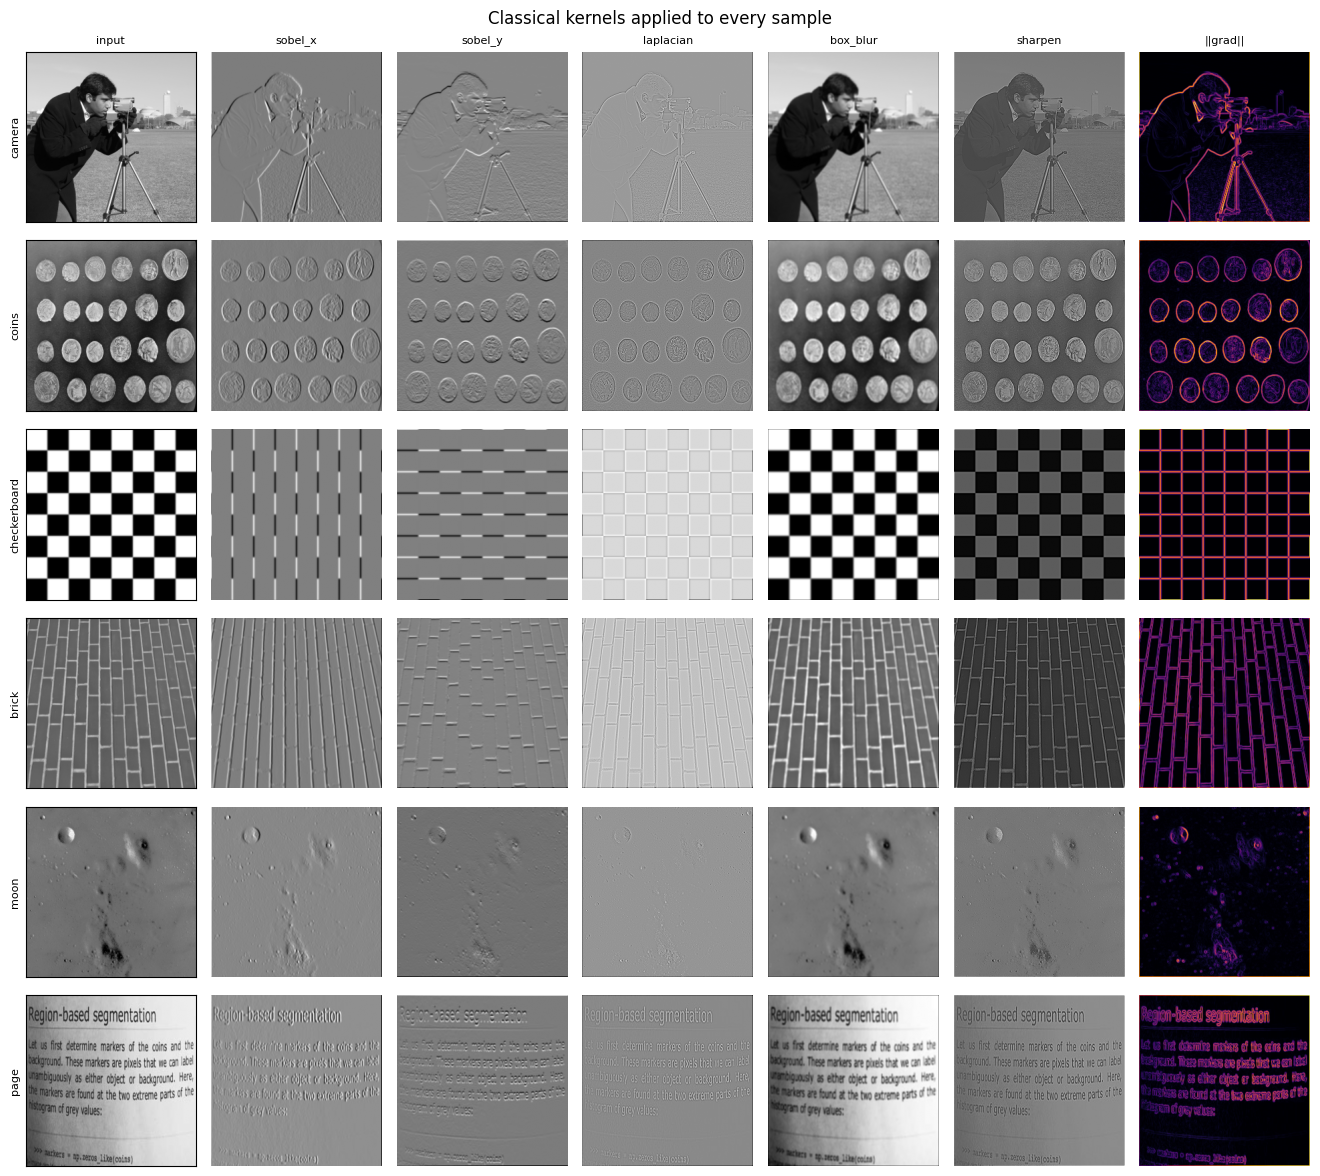

In [13]:
filter_bank = FilterBank().to(DEVICE)
with torch.no_grad():
    responses = filter_bank(batch)
    magnitude = EdgeMagnitude().to(DEVICE)(batch)

print(f"filter bank: {tuple(batch.shape)} -> {tuple(responses.shape)}  ({', '.join(filter_bank.names)})")

# One row per source image, one column per kernel.
n_images, n_kernels = batch.shape[0], responses.shape[1]
fig, axes = plt.subplots(n_images, n_kernels + 2, figsize=((n_kernels + 2) * 1.9, n_images * 2.0))

for row in range(n_images):
    axes[row, 0].imshow(batch[row, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_ylabel(names[row], fontsize=8)
    if row == 0:
        axes[row, 0].set_title("input", fontsize=8)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

    for column, kernel_name in enumerate(filter_bank.names, start=1):
        axes[row, column].imshow(responses[row, column - 1].cpu(), cmap="gray")
        if row == 0:
            axes[row, column].set_title(kernel_name, fontsize=8)
        axes[row, column].axis("off")

    axes[row, -1].imshow(magnitude[row, 0].cpu(), cmap="inferno")
    if row == 0:
        axes[row, -1].set_title("||grad||", fontsize=8)
    axes[row, -1].axis("off")

fig.suptitle("Classical kernels applied to every sample", fontsize=12)
fig.tight_layout()
plt.show()

The `checkerboard` row is the clearest read: `sobel_x` lights up only the vertical edges and
`sobel_y` only the horizontal ones — exactly what an oriented derivative should do. `box_blur`
visibly destroys the `brick` texture while barely touching `moon`, because blurring removes high
frequencies and `moon` has almost none.

### The two fits, side by side

The left pair of panels tells the story that matters. **Both** losses fall smoothly — by the usual
diagnostic, both runs "worked". Only the kernel-error curve separates them: it plunges to $10^{-7}$
for white noise and plateaus around $0.5$ for natural images, and it is the only plot that would
have caught the problem.

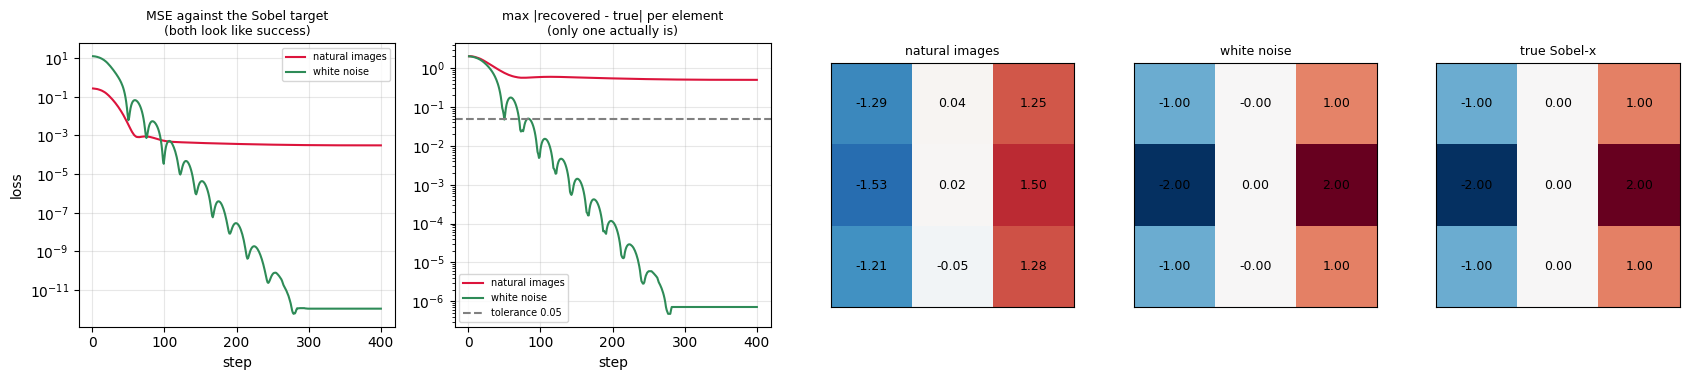

In [14]:
COLOURS: Final[dict[str, str]] = {"natural images": "crimson", "white noise": "seagreen"}

fig = plt.figure(figsize=(17, 3.9))
grid = fig.add_gridspec(1, 5, width_ratios=[1.3, 1.3, 1, 1, 1])
loss_ax, error_ax = fig.add_subplot(grid[0]), fig.add_subplot(grid[1])

for label, result in fit_results.items():
    history = result["history"]
    steps = range(1, len(history["loss"]) + 1)
    loss_ax.plot(steps, history["loss"], color=COLOURS[label], label=label)
    error_ax.plot(steps, history["kernel_error"], color=COLOURS[label], label=label)

loss_ax.set_title("MSE against the Sobel target\n(both look like success)", fontsize=9)
loss_ax.set_xlabel("step"); loss_ax.set_ylabel("loss")

error_ax.axhline(FIT_CONFIG.success_atol, ls="--", color="grey",
                 label=f"tolerance {FIT_CONFIG.success_atol}")
error_ax.set_title("max |recovered - true| per element\n(only one actually is)", fontsize=9)
error_ax.set_xlabel("step")

for ax in (loss_ax, error_ax):
    ax.set_yscale("log"); ax.grid(alpha=0.3); ax.legend(fontsize=7)

vmax = float(np.abs(truth).max())
panels = (
    ("natural images", fit_results["natural images"]["kernel"]),
    ("white noise", fit_results["white noise"]["kernel"]),
    ("true Sobel-x", truth),
)
for column, (title, matrix) in enumerate(panels, start=2):
    ax = fig.add_subplot(grid[column])
    image = ax.imshow(matrix, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    for (i, j), value in np.ndenumerate(matrix):
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

fig.tight_layout()
plt.show()

### What pooling throws away

Max-pooling keeps the strongest activation in each window; average-pooling keeps the mean. On an edge
map the difference is stark — max preserves thin edges because a single strong pixel survives, while
average dilutes them by the window area. This is why classification backbones pool with max between
blocks but use *average* pooling at the very end, where the goal is summarising evidence rather than
preserving it.

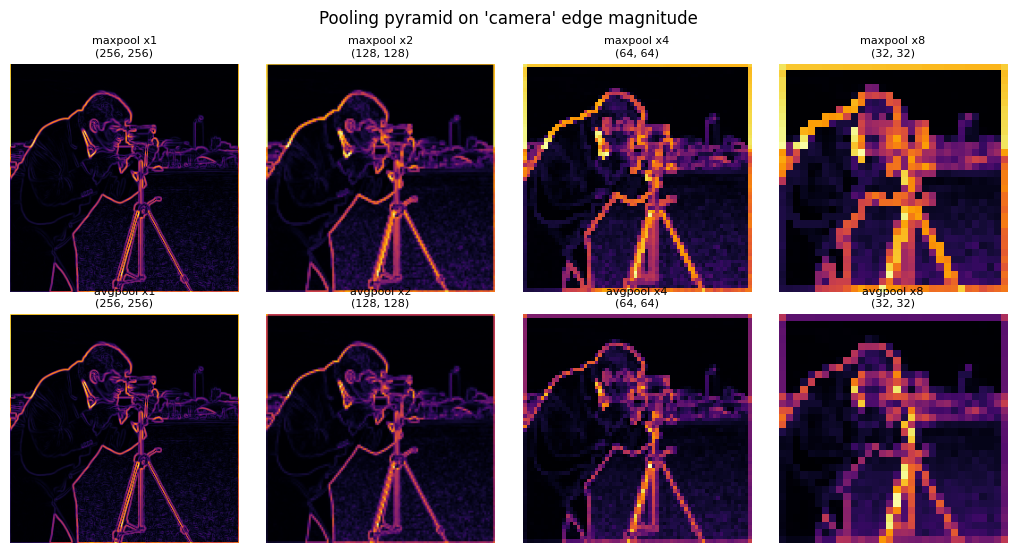

stage   resolution          pixels   retained
---------------------------------------------
0       (256, 256)          65,536    100.0%
1       (128, 128)          16,384     25.0%
2       (64, 64)             4,096      6.2%
3       (32, 32)             1,024      1.6%


In [15]:
POOL_STAGES: Final[int] = 3

with torch.no_grad():
    max_pyramid = [magnitude]
    avg_pyramid = [magnitude]
    for _ in range(POOL_STAGES):
        max_pyramid.append(F.max_pool2d(max_pyramid[-1], kernel_size=2))
        avg_pyramid.append(F.avg_pool2d(avg_pyramid[-1], kernel_size=2))

sample = 0
fig, axes = plt.subplots(2, POOL_STAGES + 1, figsize=((POOL_STAGES + 1) * 2.6, 5.6))
for column, (max_level, avg_level) in enumerate(zip(max_pyramid, avg_pyramid)):
    for row, (level, label) in enumerate(((max_level, "max"), (avg_level, "avg"))):
        axes[row, column].imshow(level[sample, 0].cpu(), cmap="inferno")
        axes[row, column].set_title(
            f"{label}pool x{2 ** column}\n{tuple(level.shape[2:])}", fontsize=8
        )
        axes[row, column].axis("off")

fig.suptitle(f"Pooling pyramid on '{names[sample]}' edge magnitude", fontsize=12)
fig.tight_layout()
plt.show()

print(f"{'stage':<8}{'resolution':<14}{'pixels':>12}{'retained':>11}")
print("-" * 45)
original_pixels = magnitude.shape[2] * magnitude.shape[3]
for stage, level in enumerate(max_pyramid):
    pixels = level.shape[2] * level.shape[3]
    print(f"{stage:<8}{str(tuple(level.shape[2:])):<14}{pixels:>12,}{pixels / original_pixels:>10.1%}")

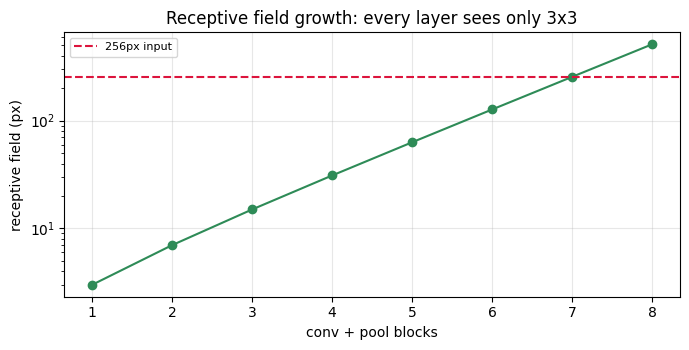

depth      receptive field   covers 256px?
------------------------------------------
1                      3x3              no
2                      7x7              no
3                    15x15              no
4                    31x31              no
5                    63x63              no
6                  127x127              no
7                  255x255              no
8                  511x511             yes


In [16]:
def receptive_field(depth: int, kernel_size: int = KERNEL_SIZE) -> int:
    """Receptive field of one unit after `depth` (conv -> 2x2 pool) blocks.

    Each 3x3 convolution adds (k - 1) at the current scale; each 2x2 pool doubles the
    scale, so the growth is geometric rather than linear.

    Args:
        depth: Number of conv+pool blocks.
        kernel_size: Convolution kernel edge length.

    Returns:
        Side length, in input pixels, of the region influencing one output unit.
    """
    field, stride = 1, 1
    for _ in range(depth):
        field += (kernel_size - 1) * stride
        stride *= 2
    return field


depths = range(1, 9)
fields = [receptive_field(d) for d in depths]

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(list(depths), fields, marker="o", color="seagreen")
ax.axhline(IMAGE_SIZE, ls="--", color="crimson", label=f"{IMAGE_SIZE}px input")
ax.set_xlabel("conv + pool blocks"); ax.set_ylabel("receptive field (px)")
ax.set_title("Receptive field growth: every layer sees only 3x3")
ax.set_yscale("log"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"{'depth':<8}{'receptive field':>18}{'covers 256px?':>16}")
print("-" * 42)
for depth, field in zip(depths, fields):
    print(f"{depth:<8}{f'{field}x{field}':>18}{'yes' if field >= IMAGE_SIZE else 'no':>16}")

---

# 7. Deployment Readiness

`EdgeMagnitude` is **fully convolutional** — it contains no `Linear` layer and no flatten, so it
imposes no constraint on input resolution. That makes it a better export subject than the classifier
in notebook 02, which is frozen at 28×28: here we can declare **batch, height *and* width** dynamic
and verify the export at resolutions it never saw during tracing, including odd, non-power-of-two
sizes.

`torch.export.Dim` names each varying axis. The `min=` bound is load-bearing: `torch.export`
specialises on any dimension it can prove is constant, and a lower bound tells it the axis is
genuinely free rather than incidentally fixed by the example input.

The same two rules from notebook 02 still apply and are enforced here:

- **`external_data=False`**, or the weights land in a `.onnx.data` sidecar and "copy the model"
  silently ships a broken artefact.
- **`eval()` before tracing.** No BatchNorm or dropout in this module, so it changes nothing today —
  which is exactly why it belongs in the habit rather than in the judgement call.

In [19]:
ONNX_OPSET: Final[int] = 18
PARITY_ATOL: Final[float] = 1e-4
PARITY_RTOL: Final[float] = 1e-3
MIN_SPATIAL: Final[int] = 16
# Deliberately awkward: odd, prime-ish, non-square, and none of them the traced size.
PARITY_SHAPES: Final[tuple[tuple[int, int, int], ...]] = (
    (1, 64, 64), (2, 97, 131), (3, 256, 128), (1, 512, 511),
)

export_model = EdgeMagnitude().to("cpu").eval()
dummy_input = torch.randn(2, 1, IMAGE_SIZE, IMAGE_SIZE)

torchscript_path = ARTIFACT_DIR / "edge_magnitude.torchscript.pt"
scripted = torch.jit.freeze(torch.jit.trace(export_model, dummy_input).eval())
scripted.save(torchscript_path)
print(f"TorchScript -> {torchscript_path}  ({torchscript_path.stat().st_size / 1024:.1f} KiB)")

onnx_path = ARTIFACT_DIR / "edge_magnitude.onnx"
sidecar = onnx_path.with_suffix(".onnx.data")
sidecar.unlink(missing_ok=True)

batch_dim = torch.export.Dim("batch")
height_dim = torch.export.Dim("height", min=MIN_SPATIAL)
width_dim = torch.export.Dim("width", min=MIN_SPATIAL)

torch.onnx.export(
    export_model,
    (dummy_input,),
    str(onnx_path),
    input_names=["image"],
    output_names=["edge_magnitude"],
    dynamic_shapes=({0: batch_dim, 2: height_dim, 3: width_dim},),
    opset_version=ONNX_OPSET,
    dynamo=True,
    external_data=False,
    verbose=False,
)
assert not sidecar.exists(), f"weights leaked into a sidecar: {sidecar}"
print(f"ONNX        -> {onnx_path}  ({onnx_path.stat().st_size / 1024:.1f} KiB, self-contained)")

session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
print(f"\nONNX input : {[(i.name, i.shape) for i in session.get_inputs()]}")
print(f"ONNX output: {[(o.name, o.shape) for o in session.get_outputs()]}")

TorchScript -> artifacts/01_convolution/edge_magnitude.torchscript.pt  (3.7 KiB)
ONNX        -> artifacts/01_convolution/edge_magnitude.onnx  (3.6 KiB, self-contained)

ONNX input : [('image', ['batch', 1, 'height', 'width'])]
ONNX output: [('edge_magnitude', ['batch', 1, 'height', 'width'])]


In [20]:
def check_export_parity(
    reference: nn.Module,
    scripted_module: torch.jit.ScriptModule,
    onnx_session: ort.InferenceSession,
    shapes: tuple[tuple[int, int, int], ...] = PARITY_SHAPES,
) -> None:
    """Assert eager, TorchScript and ONNX Runtime agree at arbitrary input resolutions.

    Args:
        reference: Eager module, eval mode, on CPU.
        scripted_module: TorchScript trace of `reference`.
        onnx_session: ONNX Runtime session over the exported graph.
        shapes: (batch, height, width) triples to test. None of these should match the
            shape used for tracing, or the test proves nothing about dynamism.

    Raises:
        AssertionError: If any backend disagrees beyond tolerance.
    """
    input_name = onnx_session.get_inputs()[0].name
    print(f"{'input':<20}{'output':<20}{'max |eager-ts|':>17}{'max |eager-onnx|':>19}")
    print("-" * 76)

    for batch_size, height, width in shapes:
        sample = torch.randn(batch_size, 1, height, width)
        with torch.no_grad():
            eager = reference(sample).numpy()
            traced = scripted_module(sample).numpy()
        exported = onnx_session.run(None, {input_name: sample.numpy()})[0]

        np.testing.assert_allclose(eager, traced, rtol=PARITY_RTOL, atol=PARITY_ATOL)
        np.testing.assert_allclose(eager, exported, rtol=PARITY_RTOL, atol=PARITY_ATOL)
        print(
            f"{str(tuple(sample.shape)):<20}{str(exported.shape):<20}"
            f"{np.abs(eager - traced).max():>17.3e}{np.abs(eager - exported).max():>19.3e}"
        )

    print(
        f"\nall backends agree within atol={PARITY_ATOL:g} at {len(shapes)} resolutions, "
        f"none of which were traced — batch, height and width are genuinely dynamic"
    )


check_export_parity(export_model, scripted, session)

input               output                 max |eager-ts|   max |eager-onnx|
----------------------------------------------------------------------------
(1, 1, 64, 64)      (1, 1, 64, 64)              0.000e+00          1.907e-06
(2, 1, 97, 131)     (2, 1, 97, 131)             0.000e+00          0.000e+00
(3, 1, 256, 128)    (3, 1, 256, 128)            0.000e+00          0.000e+00
(1, 1, 512, 511)    (1, 1, 512, 511)            0.000e+00          0.000e+00

all backends agree within atol=0.0001 at 4 resolutions, none of which were traced — batch, height and width are genuinely dynamic


In [21]:
BENCHMARK_SHAPE: Final[tuple[int, int, int, int]] = (4, 1, IMAGE_SIZE, IMAGE_SIZE)
BENCHMARK_WARMUP: Final[int] = 10
BENCHMARK_ITERATIONS: Final[int] = 50


def benchmark(fn: Callable[[], object], iterations: int = BENCHMARK_ITERATIONS) -> float:
    """Median wall-clock milliseconds per call, after warmup.

    Median rather than mean: at this timescale one scheduler preemption skews a mean badly.
    """
    for _ in range(BENCHMARK_WARMUP):
        fn()
    timings = []
    for _ in range(iterations):
        started = time.perf_counter()
        fn()
        timings.append((time.perf_counter() - started) * 1_000)
    return float(np.median(timings))


benchmark_input = torch.randn(*BENCHMARK_SHAPE)
benchmark_numpy = benchmark_input.numpy()
onnx_input_name = session.get_inputs()[0].name

with torch.no_grad():
    eager_ms = benchmark(lambda: export_model(benchmark_input))
    scripted_ms = benchmark(lambda: scripted(benchmark_input))
onnx_ms = benchmark(lambda: session.run(None, {onnx_input_name: benchmark_numpy}))

print(f"CPU latency, input {BENCHMARK_SHAPE}, median of {BENCHMARK_ITERATIONS} runs\n")
print(f"{'backend':<18}{'ms':>10}{'vs eager':>11}")
print("-" * 39)
for label, milliseconds in (
    ("PyTorch eager", eager_ms),
    ("TorchScript", scripted_ms),
    ("ONNX Runtime", onnx_ms),
):
    print(f"{label:<18}{milliseconds:>10.3f}{eager_ms / milliseconds:>10.2f}x")

CPU latency, input (4, 1, 256, 256), median of 50 runs

backend                   ms   vs eager
---------------------------------------
PyTorch eager          3.934      1.00x
TorchScript            3.752      1.05x
ONNX Runtime           3.504      1.12x


---

## What this notebook demonstrated

1. **Convolution is nine multiply-adds in a sliding window** — provable by writing the loop and
   checking it against cuDNN. The three-orders-of-magnitude gap between the loop and `F.conv2d` is
   the entire reason `im2col` and GEMM-based kernels exist.
2. **Framework "convolution" is cross-correlation.** No kernel flip. Irrelevant when the kernel is
   learned, essential when comparing against a hand-specified one.
3. **The kernel is just a parameter.** Gradient descent recovered Sobel-x exactly, from nothing but
   its effect on images — the mechanism every subsequent notebook relies on, shown at a scale where
   the right answer is known in advance and checkable element by element.
4. **A low loss is not a correct model.** The same fit on natural images reached an MSE of ~4 × 10⁻⁴
   and still got the kernel wrong by ~0.5 per element, because correlated inputs make the parameters
   unidentifiable. The loss curve looked fine. Only comparing against ground truth caught it — and
   in real work there is no ground truth to compare against, which is why held-out data,
   augmentation and honest evaluation design carry so much weight.
5. **Fully-convolutional models export with fully dynamic shapes**, verified at resolutions never
   traced, including 97×131 and 512×511.

## What comes next

Section 5 learned **one** kernel from a known target. A real classifier learns **hundreds**, in
stacked layers, from nothing but image-label pairs — no target filter to imitate, only a loss that
says whether the final answer was right.

→ **[02 · MLP vs CNN](02_image_classification_mlp_vs_cnn.ipynb)** puts that to work and measures what
the convolutional prior is worth: better accuracy from 2.5× fewer parameters.